In [1]:
"""""
This script is used for the results for the third research question.
Made by: Bram Bouman
date: 17/06/2026
"""

import pandas as pd 

#load in the data:
CR_db = pd.read_csv("processed_CR_db.csv")
patent_db = pd.read_csv("processed_patents.csv")

#drop first column, because it is extra and is not wanted: 
CR_db = CR_db.iloc[:, 1:]
patent_db = patent_db.iloc[:,1:]


#change european countries to europe, because they are all their own stakeholder
europe = ["Finland", "France", "Germany", "United Kingdom", "Sweden"]
CR_db["country"] = CR_db["country"].replace(europe, "Europe")
patent_db["country"] = patent_db["country"].replace(europe, "Europe")

C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\165469066.py:10: DtypeWarning: Columns (0: abstract, 1: secretary_remarks, 2: ainumber, 3: ainame, 4: revisionof, 5: revisedto, 6: release, 7: crspec, 8: crspecversion, 9: workitem, 10: crnumber, 11: uicc_affected, 12: me_affected, 13: ran_affected, 14: cn_affected, 15: clauses_affected, 16: crsinpack) have mixed types. Specify dtype option on import or set low_memory=False.
  CR_db = pd.read_csv("processed_CR_db.csv")


         country  local patent technologies  amount change requests  \
0          China                   0.373700                  361416   
2         Europe                   0.288584                  307915   
1  United States                   0.314559                  119099   
4    South Korea                   0.171696                   56972   
3          Japan                   0.220176                   29272   

   fraction patent coop treaty  
0                     0.286904  
2                     0.212404  
1                     0.179989  
4                     0.263162  
3                     0.244458  


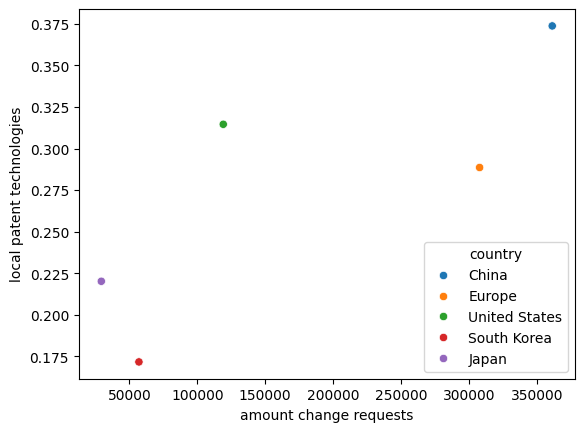

In [26]:
def local_patent_technologies(country):
    CR_db_country = CR_db[CR_db["country"] == country]
    N_CR = len(CR_db_country["country"] == country)
    if (country == "South Korea"):
        country = "Korea"
        patent_db["country"] = patent_db["country"].replace("South Korea", "Korea")
    
    patent_db_country = patent_db[patent_db["country"] == country]

    stakeholders = patent_db_country["company"].unique()
    N_stakeholders = len(stakeholders)
    
    european_countries = [
        "GERMANY", "FRANCE", 
        "UNITED KINGDOM", "SWEDEN", "FINLAND"
    ]

    pattern = "|".join(european_countries)

    mask = patent_db_country["country_of_registration"].str.contains(
        pattern,
        case=False,
        na=False
    )

    patent_db_country.loc[mask, "country_of_registration"] = "Europe"
    

    patent_db_country["match_registration_and_origin"] = patent_db_country.apply(
        lambda row: 1 if str(row["country"]).lower() in str(row["country_of_registration"]).lower() else 0,
        axis=1
    )
    
    patent_coop_treaty = (patent_db_country["country_of_registration"]=="WO Patent Cooperation Treaty").sum()
    fraction_pct = patent_coop_treaty/len(patent_db_country["country_of_registration"])

    local_patents = 0
    for stakeholder in stakeholders:
        stakeholder_db = patent_db_country[patent_db_country["company"] == stakeholder]
        stakeholder_total_patents = len(stakeholder_db["country_of_registration"])
        stakeholder_local_patents = stakeholder_db["match_registration_and_origin"].sum()
        stakeholder_score = stakeholder_local_patents/stakeholder_total_patents
        local_patents = local_patents + stakeholder_score
    
    answer = 1/N_stakeholders*local_patents
    return answer, N_CR, fraction_pct


countries = ["China", "United States", "Europe", "Japan", "South Korea"]
answer = pd.DataFrame(columns = ["country", "local patent technologies", "amount change requests", "fraction patent coop treaty"])
for country in countries: 
    local_patent_technologies_answer, N_CR, frac_pct = local_patent_technologies(country)
    answer.loc[len(answer)] = [country, local_patent_technologies_answer, N_CR,frac_pct]

answer["country"] = answer["country"].replace("Korea", "South Korea")
answer = answer.sort_values(by = "amount change requests", ascending = False)
print(answer)

import matplotlib.pyplot as plt

import seaborn as sns
plt.figure()
sns.scatterplot(data=answer, x="amount change requests", y="local patent technologies", hue="country")
plt.show()

In [16]:
from scipy.stats import pearsonr
r, p_value = pearsonr(answer["amount change requests"], answer["local patent technologies"])
print("Correlation:", r)
print("P-value:", p_value)

Correlation: 0.7990861767026355
P-value: 0.10478685632071612


C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\1993956793.py:21: RuntimeWarning: invalid value encountered in scalar divide
  local_patents = stakeholder_local_patents/stakeholder_total_patents
C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\1993956793.py:21: RuntimeWarning: invalid value encountered in scalar divide
  local_patents = stakeholder_local_patents/stakeholder_total_patents
C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\1993956793.py:21: RuntimeWarning: invalid value encountered in scalar divide
  local_patents = stakeholder_local_patents/stakeholder_total_patents
C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\1993956793.py:21: RuntimeWarning: invalid value encountered in scalar divide
  local_patents = stakeholder_local_patents/stakeholder_total_patents
C:\Users\Bram\AppData\Local\Temp\ipykernel_100440\1993956793.py:21: RuntimeWarning: invalid value encountered in scalar divide
  local_patents = stakeholder_local_patents/stakeholder_total_patents


             company        country  local patent technologies  \
0             huawei          China                   0.295741   
1           ericsson         Europe                   0.152513   
2          hisilicon          China                        NaN   
3              nokia         Europe                   0.153421   
4                zte          China                   0.342767   
5           qualcomm  United States                   0.171993   
6            samsung          Korea                   0.182012   
7               catt          China                   0.507137   
8              intel  United States                   0.223014   
9         ntt docomo          Japan                   0.163223   
10      china mobile          China                   0.678598   
11                lg          Korea                   0.109092   
12              vivo          China                   0.332354   
13     china telecom          China                        NaN   
14        

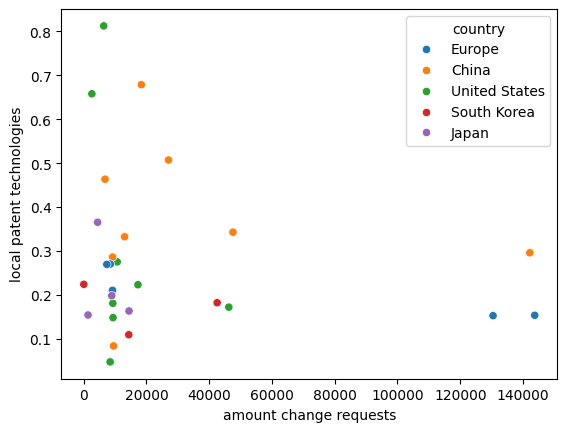

In [9]:
def local_patent_technologies(stakeholder): 
    CR_db_stakeholder = CR_db[CR_db["source"] == stakeholder]
    country = CR_db_stakeholder["country"].unique()[0]
    N_CR = len(CR_db_stakeholder["source"] == stakeholder)
    if (country == "South Korea"):
        country = "Korea"
        patent_db["country"] = patent_db["country"].replace("South Korea", "Korea")
    
    patent_db_stakeholder = patent_db[patent_db["company"] == stakeholder]
    
    

    patent_db_stakeholder["match_registration_and_origin"] = patent_db_stakeholder.apply(
        lambda row: 1 if str(row["country"]).lower() in str(row["country_of_registration"]).lower() else 0,
        axis=1
    )

    
    stakeholder_total_patents = len(patent_db_stakeholder["country_of_registration"])
    stakeholder_local_patents = patent_db_stakeholder["match_registration_and_origin"].sum()
    local_patents = stakeholder_local_patents/stakeholder_total_patents
    
    answer = local_patents
    return answer, N_CR, country


companies = [
    "huawei", "ericsson", "hisilicon", "nokia", "zte", "qualcomm",
    "samsung", "catt", "intel", "ntt docomo", "china mobile",
    "lg", "vivo", "china telecom",
    "orange", "lenovo", "apple", "rohde schwarz", "oppo",
    "nec", "att", "interdigital", "deutsche telekom",
    "vodafone", "xiaomi", "motorola", "verizon",
    "keysight", "tmobile", "att",
    "kddi", "cisco", "sharp", "wilus"
]
answer = pd.DataFrame(columns = ["company", "country", "local patent technologies", "amount change requests"])
for company in companies: 
    local_patent_technologies_answer, N_CR, country = local_patent_technologies(company)
    answer.loc[len(answer)] = [company, country, local_patent_technologies_answer, N_CR]
print(answer)

answer["country"] = answer["country"].replace("Korea", "South Korea")
answer = answer.sort_values(by = "amount change requests", ascending = False)

import matplotlib.pyplot as plt

import seaborn as sns
plt.figure()
sns.scatterplot(data=answer, x="amount change requests", y="local patent technologies", hue = "country")
plt.show()

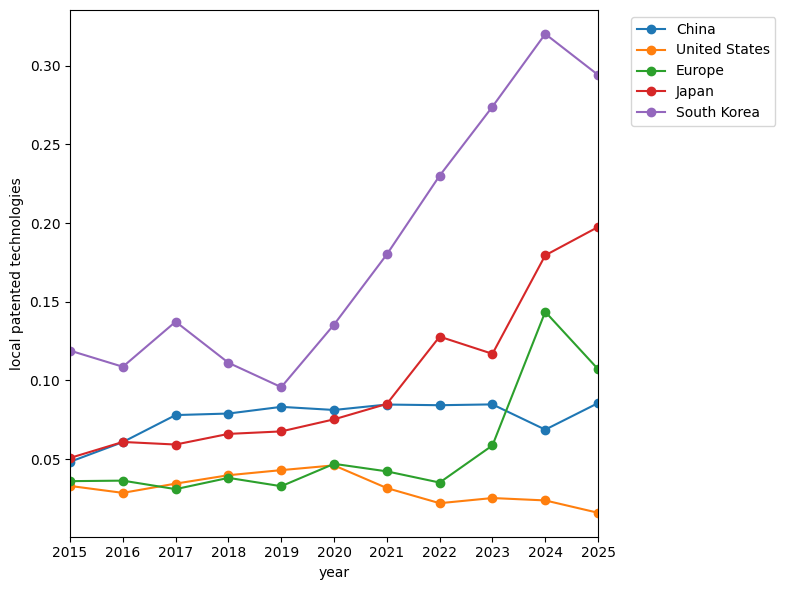

In [37]:
def local_patent_technologies_year(country, year):
    if (country == "South Korea"):
        country = "Korea"
        patent_db["country"] = patent_db["country"].replace("South Korea", "Korea")
        
    
    patent_db_country = patent_db[patent_db["country"] == country]
    patent_db_country = patent_db_country[patent_db_country["years"] == year]
    

    stakeholders = patent_db_country["company"].unique()
    N_stakeholders = len(stakeholders)
    

    patent_db_country["match_registration_and_origin"] = patent_db_country.apply(
        lambda row: 1 if str(row["country"]).lower() in str(row["country_of_registration"]).lower() else 0,
        axis=1
    )

    total_country_of_registration = patent_db[patent_db["years"] == year]
    total_country_of_registration = total_country_of_registration["country_of_registration"].str.contains(f"{country}", case=False, na=False).sum()
    
    local_patents = 0
    for stakeholder in stakeholders:
        stakeholder_db = patent_db_country[patent_db_country["company"] == stakeholder]
        stakeholder_local_patents = stakeholder_db["match_registration_and_origin"].sum()
        local_patents = local_patents + stakeholder_local_patents
    
    answer = 1/(N_stakeholders*total_country_of_registration)*local_patents
    return answer


countries = ["China", "United States", "Europe", "Japan", "South Korea"]
answer = pd.DataFrame(columns = countries)
years = list(range(2006,2026))

for year in years:
    temp_answer = []
    for country in countries: 
        local_patent_technologies_answer = local_patent_technologies_year(country,year)
        temp_answer.append(local_patent_technologies_answer)
    answer.loc[len(answer)] = temp_answer


import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for column in answer.columns:
    plt.plot(years,answer[column], label = column, marker = "o")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("year")
plt.ylabel("local patented technologies")
plt.xlim(2015,2025)
plt.xticks(range(2015, 2026))
plt.tight_layout()
plt.show()


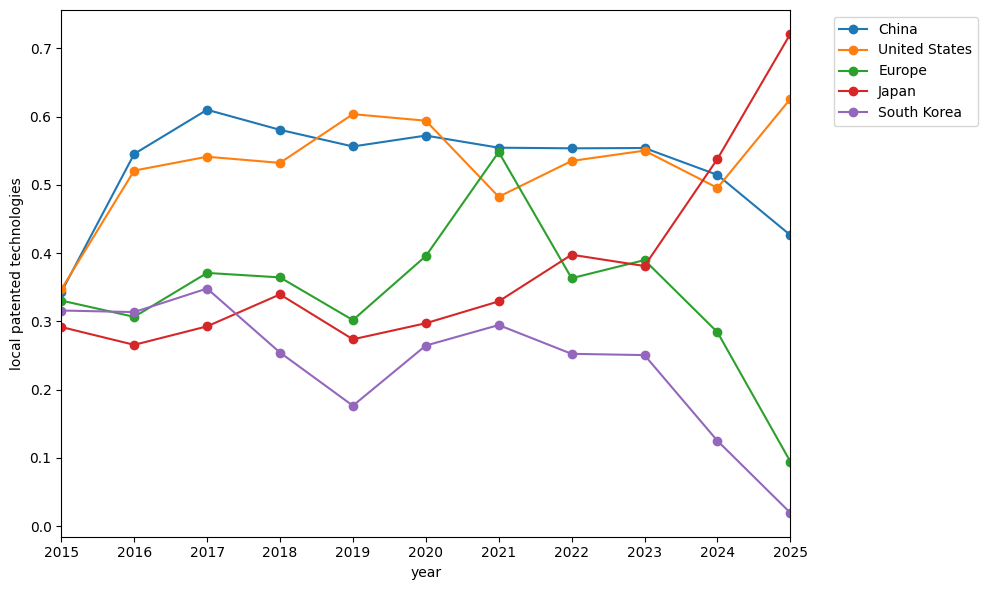

In [30]:
def local_patent_technologies_year(country, year):
    if (country == "South Korea"):
        country = "Korea"
        patent_db["country"] = patent_db["country"].replace("South Korea", "Korea")
        
    
    patent_db_country = patent_db[patent_db["country"] == country]
    patent_db_country = patent_db_country[patent_db_country["years"] == year]
    patent_db_country = patent_db_country[patent_db_country["country_of_registration"] !="WO Patent Cooperation Treaty"]
    

    stakeholders = patent_db_country["company"].unique()
    N_stakeholders = len(stakeholders)
    european_countries = [
        "GERMANY", "FRANCE", 
        "UNITED KINGDOM", "SWEDEN", "FINLAND"
    ]

    pattern = "|".join(european_countries)

    mask = patent_db_country["country_of_registration"].str.contains(
        pattern,
        case=False,
        na=False
    )

    patent_db_country.loc[mask, "country_of_registration"] = "Europe"
    


    

    patent_db_country["match_registration_and_origin"] = patent_db_country.apply(
        lambda row: 1 if str(row["country"]).lower() in str(row["country_of_registration"]).lower() else 0,
        axis=1
    )

    local_patents = 0
    for stakeholder in stakeholders:

        stakeholder_db = patent_db_country[patent_db_country["company"] == stakeholder]
        stakeholder_total_patents = len(stakeholder_db["country_of_registration"])
        stakeholder_local_patents = stakeholder_db["match_registration_and_origin"].sum()
        stakeholder_score = stakeholder_local_patents/stakeholder_total_patents
        local_patents = local_patents + stakeholder_score
    
    answer = 1/(N_stakeholders)*local_patents
    return answer


countries = ["China", "United States", "Europe", "Japan", "South Korea"]
answer = pd.DataFrame(columns = countries)
years = list(range(2006,2026))

for year in years:
    temp_answer = []
    for country in countries: 
        local_patent_technologies_answer = local_patent_technologies_year(country,year)
        temp_answer.append(local_patent_technologies_answer)
    answer.loc[len(answer)] = temp_answer


import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
for column in answer.columns:
    plt.plot(years,answer[column], label = column, marker = "o")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("year")
plt.ylabel("local patented technologies")
plt.xlim(2015,2025)
plt.xticks(range(2015, 2026))
plt.tight_layout()
plt.show()


In [37]:
test = patent_db[patent_db["years"] == 2025]
test = test[test["country"] == "Korea"]
print((test["country_of_registration"] != "WO Patent Cooperation Treaty").sum())

302
